# Analisis exploratorio de datos EDA


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns   
from datetime import datetime, timedelta

In [3]:
np.random.seed(42)
n_rows=500
data={
    'producto':np.random.choice(['Laptop','mouse','teclado','monitor','cables'],n_rows),
    'monto':np.random.uniform(100,2000,n_rows).round(2),
    'cantidad':np.random.randint(1,10,n_rows),
    'fecha':[datetime(2025,1,1)+timedelta(days=np.random.randint(0,365)) for _ in range(n_rows)],
    'zona':np.random.choice(['Norte','Sur','Este','Oeste','Centro'],n_rows)
}

df=pd.DataFrame(data)
print(df)
print(df['cantidad'].unique())

    producto    monto  cantidad      fecha    zona
0    monitor  1059.98         3 2025-03-07  Centro
1     cables  1670.27         4 2025-12-01    Este
2    teclado   708.09         2 2025-09-19     Sur
3     cables  1801.49         2 2025-10-22   Oeste
4     cables   839.48         1 2025-08-31    Este
..       ...      ...       ...        ...     ...
495   Laptop  1803.04         9 2025-11-30     Sur
496  teclado   124.70         4 2025-01-20    Este
497   Laptop   262.47         5 2025-05-26  Centro
498   Laptop   494.98         2 2025-11-12    Este
499   Laptop   150.41         4 2025-06-09    Este

[500 rows x 5 columns]
[3 4 2 1 5 7 6 9 8]


### EDA: RESPONDIENDO A PREGUNTAS PLANTEADAS

In [4]:
df.describe()

,monto,cantidad,fecha
count,500.000000,500.000000,500
mean,1029.821700,4.968000,2025-07-05 07:23:31.200000
min,108.800000,1.000000,2025-01-01 00:00:00
25%,524.060000,3.000000,2025-04-12 00:00:00
50%,1017.380000,5.000000,2025-06-22 00:00:00
75%,1520.257500,7.000000,2025-10-12 06:00:00
max,1999.460000,9.000000,2025-12-31 00:00:00
std,558.279431,2.642905,NaN


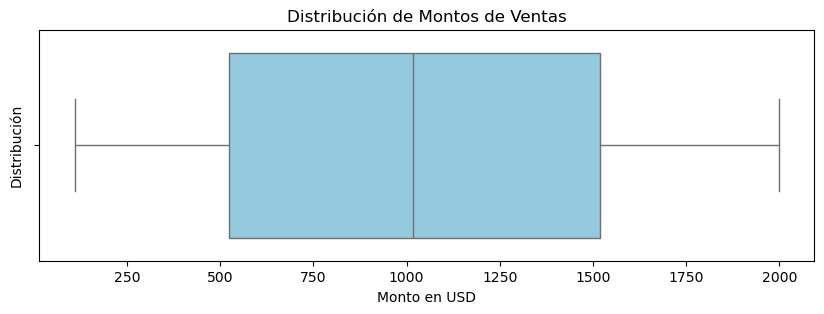

In [5]:
# pregunta1: ¿Como se distribuyen los montos de las ventas ? (identificar outliers)
plt.figure(figsize=(10,3)) # define el tamaño de la figura
sns.boxplot(x=df['monto'],color='skyblue')
plt.title('Distribución de Montos de Ventas')
plt.xlabel('Monto en USD')
plt.ylabel('Distribución')
plt.show()  


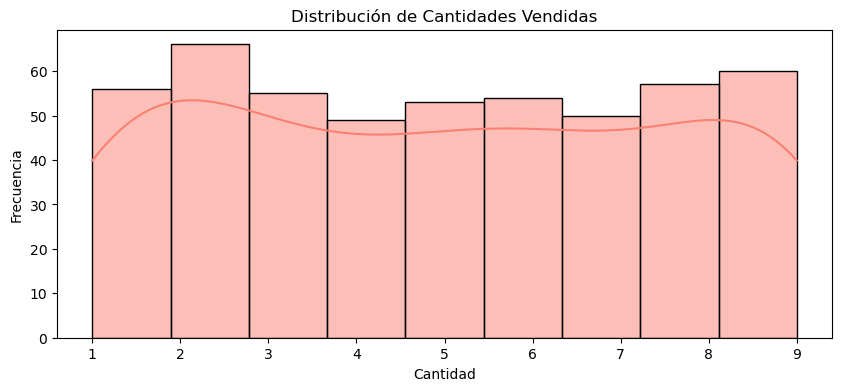

In [6]:
#histograma de cantidades vendidas
#cantidad varia de 
plt.figure(figsize=(10,4))
sns.histplot(df['cantidad'], bins=9, kde=True, color='salmon')
plt.title('Distribución de Cantidades Vendidas')    
plt.xlabel('Cantidad')
plt.ylabel('Frecuencia')
plt.show()

     zona      monto
0  Centro   97211.69
1    Este   97072.27
2   Norte   97114.47
3   Oeste  119475.97
4     Sur  104036.45


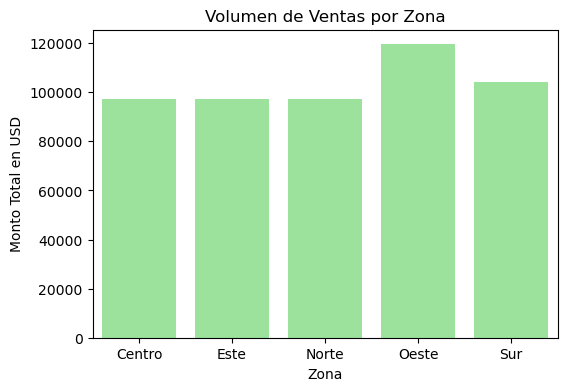

In [7]:
#Pregunta 2: ¿cual es el volumen de ventas por zona?
ventas_por_zona=df.groupby('zona')['monto'].sum().reset_index()
print(ventas_por_zona)
plt.figure(figsize=(6,4))
sns.barplot(x='zona',y='monto',data=ventas_por_zona, color='lightgreen')
plt.title('Volumen de Ventas por Zona') 
plt.xlabel('Zona')
plt.ylabel('Monto Total en USD')
plt.show()


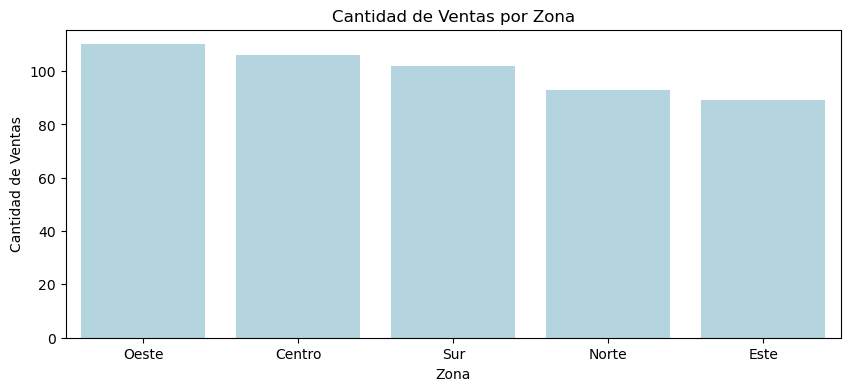

In [8]:
plt.figure(figsize=(10,4))
sns.countplot(data=df,x='zona',order=df['zona'].value_counts().index, color='lightblue')
plt.title('Cantidad de Ventas por Zona')
plt.xlabel('Zona')
plt.ylabel('Cantidad de Ventas')
plt.show()

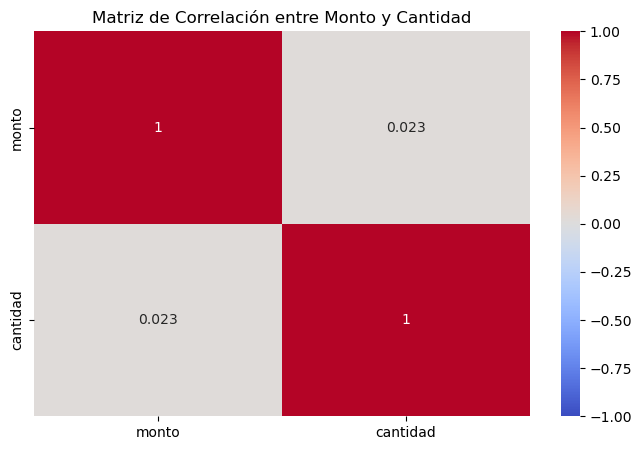

In [9]:
#pregunta 3: ¿existe alguna correlacion entre la cantidad de productos comprados y el monto?
plt.figure(figsize=(8,5))
matriz_correlacion=df[['monto','cantidad']].corr()
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Monto y Cantidad')
plt.show()

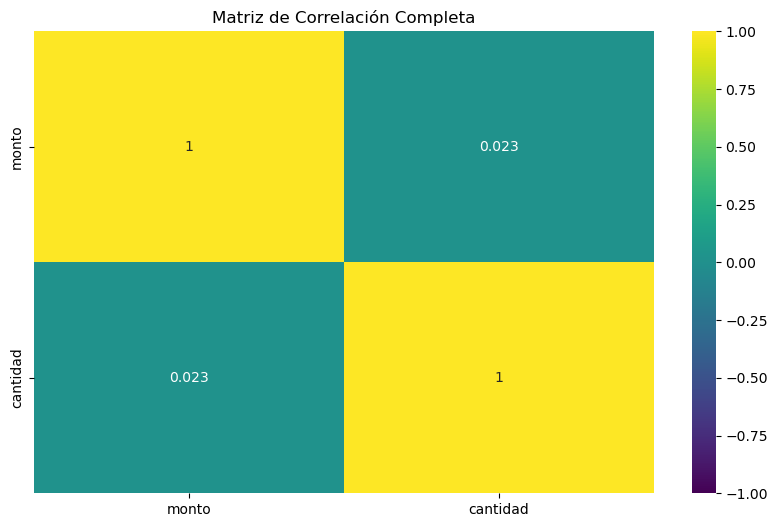

In [10]:
#matriz de correlacion entre todas las variables numericas
plt.figure(figsize=(10,6))
df_numerico = df.select_dtypes(include=['number'])
matriz_correlacion_completa = df_numerico.corr()
sns.heatmap(matriz_correlacion_completa, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Matriz de Correlación Completa')
plt.show()

     zona  cantidad
0  Centro       498
1    Este       487
2   Norte       435
3   Oeste       545
4     Sur       519


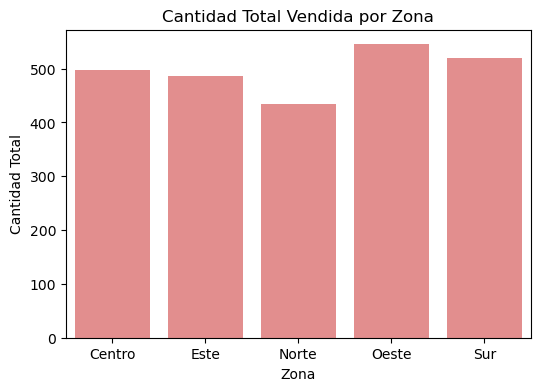

In [11]:
#cantidad total vendida por zona
cantidad_por_zona=df.groupby('zona')['cantidad'].sum().reset_index()
print(cantidad_por_zona)
plt.figure(figsize=(6,4))
sns.barplot(x='zona',y='cantidad',data=cantidad_por_zona, color='lightcoral')
plt.title('Cantidad Total Vendida por Zona')
plt.xlabel('Zona')
plt.ylabel('Cantidad Total')
plt.show()

      zona producto  cantidad
0   Centro   Laptop       127
1   Centro   cables        66
2   Centro  monitor       113
3   Centro    mouse        78
4   Centro  teclado       114
5     Este   Laptop       100
6     Este   cables        84
7     Este  monitor       121
8     Este    mouse        95
9     Este  teclado        87
10   Norte   Laptop        78
11   Norte   cables        79
12   Norte  monitor       106
13   Norte    mouse       113
14   Norte  teclado        59
15   Oeste   Laptop       133
16   Oeste   cables       138
17   Oeste  monitor        97
18   Oeste    mouse        64
19   Oeste  teclado       113
20     Sur   Laptop       132
21     Sur   cables       100
22     Sur  monitor       113
23     Sur    mouse       105
24     Sur  teclado        69


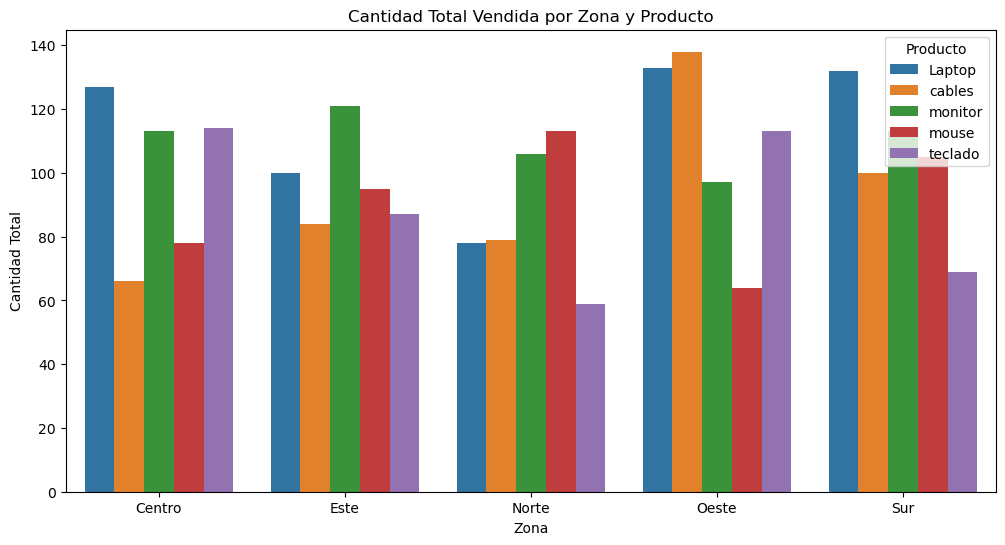

In [12]:
#cantidad total vendida por zona y producto
cantidad_zona_producto=df.groupby(['zona','producto'])['cantidad'].sum().reset_index()
print(cantidad_zona_producto)
plt.figure(figsize=(12,6))
sns.barplot(x='zona',y='cantidad',hue='producto',data=cantidad_zona_producto)
plt.title('Cantidad Total Vendida por Zona y Producto')
plt.xlabel('Zona')
plt.ylabel('Cantidad Total')
plt.legend(title='Producto')
plt.show()

In [13]:
#cantidad de productos vendidos por zona y producto
cantidad_zona_producto=df.groupby(['zona','producto'])['cantidad'].sum().reset_index()
#encontrar el producto mas vendido por zona
idx=cantidad_zona_producto.groupby('zona')['cantidad'].idxmax()
productos_mas_vendidos=cantidad_zona_producto.loc[idx].sort_values(by="cantidad",ascending=False)
print(productos_mas_vendidos)


      zona producto  cantidad
16   Oeste   cables       138
20     Sur   Laptop       132
0   Centro   Laptop       127
7     Este  monitor       121
13   Norte    mouse       113


   semestre  cantidad
0         1      1281
1         2      1203


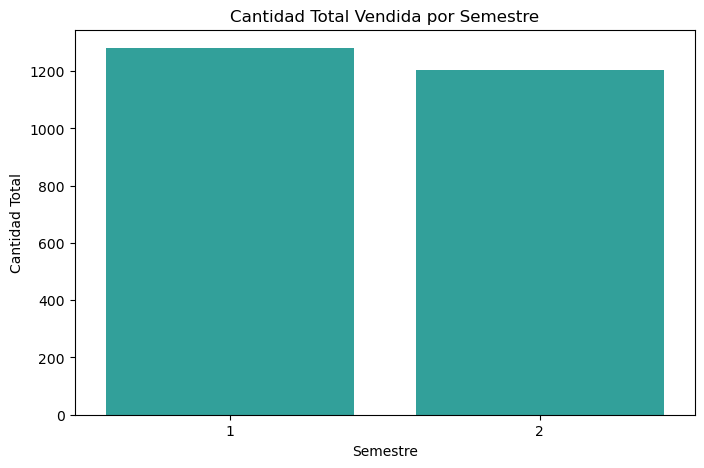

In [14]:

plt.figure(figsize=(8,5))

df['semestre'] = ((df['fecha'].dt.month - 1) // 6) + 1
cantidad_por_semestre = df.groupby('semestre')['cantidad'].sum().reset_index()

print(cantidad_por_semestre)

sns.barplot(x='semestre', y='cantidad', data=cantidad_por_semestre, color='lightseagreen')

plt.title('Cantidad Total Vendida por Semestre')
plt.xlabel('Semestre')
plt.ylabel('Cantidad Total')
plt.show()

In [15]:
#ahora por trimestre
#crear columna trimestre
df["trimestre"] = df['fecha'].dt.to_period('Q')

#agrupar la cantidad total por producto y trimestre
ventas_trimestrales=df.groupby(['trimestre','producto'])['cantidad'].sum().reset_index()

#pivotearlo para mostrar en formato de tabla
tabla_resumen_trimestral = ventas_trimestrales.pivot(index="producto",columns="trimestre",values="cantidad")
print(tabla_resumen_trimestral)

trimestre  2025Q1  2025Q2  2025Q3  2025Q4
producto                                 
Laptop        140     154      95     181
cables         93     146      84     144
monitor       113     150     139     148
mouse         110     121      87     137
teclado       111     143      88     100


        mes  cantidad
0   2025-01       202
1   2025-02       150
2   2025-03       215
3   2025-04       209
4   2025-05       264
5   2025-06       241
6   2025-07       105
7   2025-08       215
8   2025-09       173
9   2025-10       304
10  2025-11       207
11  2025-12       199


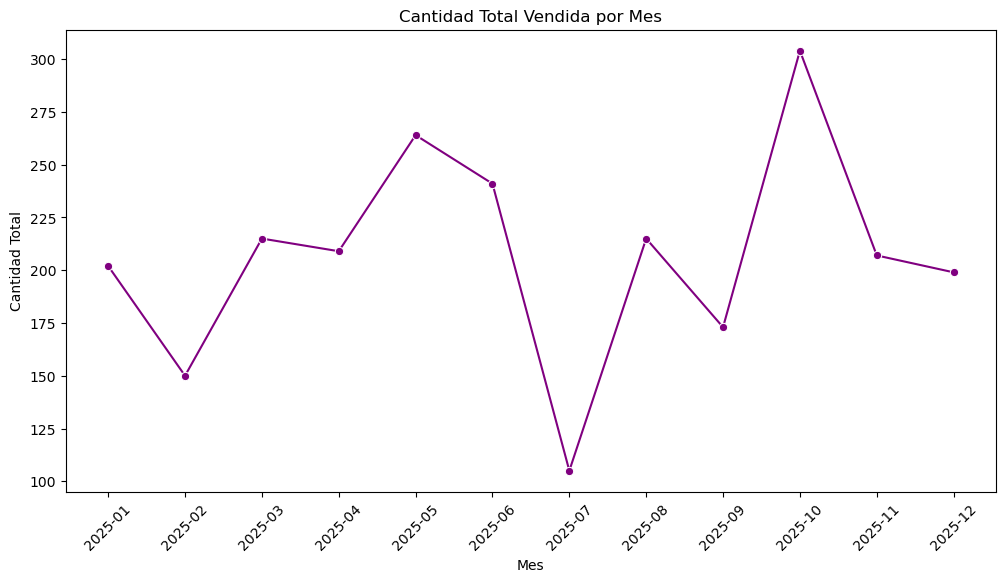

In [17]:
#agrupar la cantidad total de productos vendidos por mes
df['mes'] = df['fecha'].dt.to_period('M').astype(str)
ventas_mensuales=df.groupby('mes')['cantidad'].sum().reset_index()
print(ventas_mensuales)
plt.figure(figsize=(12,6))
sns.lineplot(x='mes',y='cantidad',data=ventas_mensuales, marker='o', color='purple')
plt.title('Cantidad Total Vendida por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad Total')
plt.xticks(rotation=45)
plt.show()

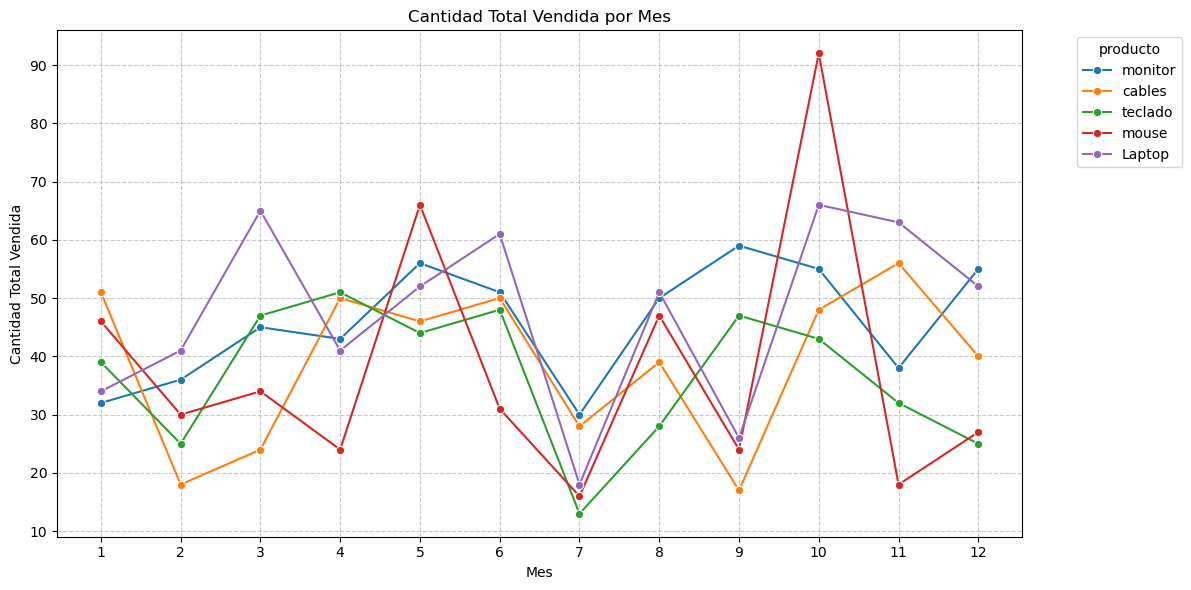

In [27]:
#visualizacion de tendencias de productos vendidos por mes
plt.figure(figsize=(12,6))
sns.lineplot(x='mes',y='cantidad',data=df,estimator="sum", marker='o', errorbar=None, hue='producto')
plt.title('Cantidad Total Vendida por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad Total Vendida')
plt.xticks(range(1, 13))
plt.grid(True,linestyle='--', alpha=0.7)
plt.legend(title='producto',bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

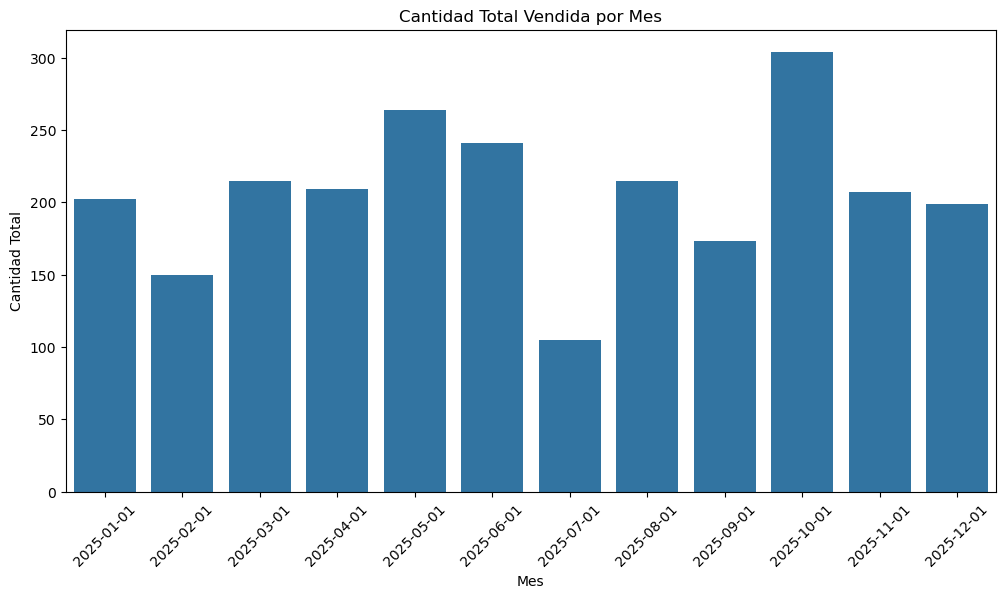

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(x='mes', y='cantidad', data=ventas_mensuales)

plt.title('Cantidad Total Vendida por Mes')
plt.xlabel('Mes')
plt.ylabel('Cantidad Total')
plt.xticks(rotation=45)

plt.show()

In [21]:
df['mes']=df["fecha"].dt.month
#agrupar la cantidad total de productos vendidos por mes en una tabla
tabla_mensual=df.pivot_table(
    index='producto',
    columns='mes',
    values='cantidad',
    aggfunc='sum',
    fill_value=0
)

print(tabla_mensual)
display(tabla_mensual)

mes       1   2   3   4   5   6   7   8   9   10  11  12
producto                                                
Laptop    34  41  65  41  52  61  18  51  26  66  63  52
cables    51  18  24  50  46  50  28  39  17  48  56  40
monitor   32  36  45  43  56  51  30  50  59  55  38  55
mouse     46  30  34  24  66  31  16  47  24  92  18  27
teclado   39  25  47  51  44  48  13  28  47  43  32  25


mes,1,2,3,4,5,6,7,8,9,10,11,12
producto,,,,,,,,,,,,
Laptop,34,41,65,41,52,61,18,51,26,66,63,52
cables,51,18,24,50,46,50,28,39,17,48,56,40
monitor,32,36,45,43,56,51,30,50,59,55,38,55
mouse,46,30,34,24,66,31,16,47,24,92,18,27
teclado,39,25,47,51,44,48,13,28,47,43,32,25


In [29]:
pip install ydata-profiling

Note: you may need to restart the kernel to use updated packages.


In [30]:
from ydata_profiling import ProfileReport
#generar el reporte de perfilado
profile=ProfileReport(df, title="Reporte de Perfilado de Ventas", explorative=True)
profile

#guardar el reporte en un archivo HTML
profile.to_file("reporte_perfilado_ventas.html")


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 8/8 [00:00<00:00, 553.94it/s]
c:\Users\l\anaconda3\Lib\site-packages\ydata_profiling\model\pandas\discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2 3 1 1 0 4 3 1 2 7 7 3 4 4 6 9 1 4 2 3 6 8 0 8 7 0 1 2 0 9 8 1 9 7 9 6 6
 3 1 7 4 6 1 4 3 9 6 1 0 4 9 6 7 4 6 4 9 6 8 1 9 4 7 0 4 1 6 0 2 4 3 2 4 8
 3 0 7 8 2 6 1 7 8 6 6 4 8 0 3 3 2 2 3 0 1 9 1 4 9 9 8 0 0 9 8 9 7 2 2 1 4
 2 6 1 2 4 0 0 9 7 0 8 2 8 4 0 7 4 6 6 8 9 1 9 9 7 0 7 4 6 7 4 7 9 2 8 1 7
 1 3 7 2 1 7 0 8 2 1 2 4 8 7 7 7 8 0 3 6 9 1 0 1 7 2 1 7 1 2 7 3 0 4 9 8 9
 9 7 3 4 0 0 2 8 1 3 1 4 9 0 4 9 0 9 8 3 4 4 6 7 8 8 1 9 7 3 3 8 3 6 4 2 1
 9 9 0 2 8 6 4 4 6 7 0 9 2 3 0 2 1 1 0 8 2 2 6 8 9 9 3 4 1 9 8 2 9 2 9 1 9
 8 9 4 1 8 6 8 4 1 6 4 4 0 1 8 2 2 8 8 1 8 0 6 8 2 8 0 9 9 4 3 6 7 4 9 2 7
 4 7 1 3 1 7 1 0 9 0 8 1 8 2 6 2 7 9 1 4 6 3 3 3 1 3 0 6 0 6 0 6 8 1 1 3 2
 3 7 0 6 2 7 1 1 3 0 2 9 7 7 3 1 3 6 2 0 8 4 4 3 6 2 9 4 2 0 6 1 2 

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
pip install sweetviz

   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   --- ------------------------------------ 1.3/15.1 MB 6.1 MB/s eta 0:00:03
   -------- ------------------------------- 3.1/15.1 MB 8.8 MB/s eta 0:00:02
   ------------- -------------------------- 5.2/15.1 MB 8.6 MB/s eta 0:00:02
   ---------------- ----------------------- 6.3/15.1 MB 8.4 MB/s eta 0:00:02
   ---------------------- ----------------- 8.4/15.1 MB 8.1 MB/s eta 0:00:01
   ------------------------- -------------- 9.7/15.1 MB 7.5 MB/s eta 0:00:01
   ------------------------------ --------- 11.5/15.1 MB 8.0 MB/s eta 0:00:01
   --------------------------------- ------ 12.8/15.1 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------  14.9/15.1 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 15.1/15.1 MB 7.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [32]:
import sweetviz
#generar el reporte de sweetviz
reporte_sweetviz=sweetviz.analyze(df)

#generar y guardar reporte
reporte_sweetviz.show_html("reporte_sweetviz_ventas.html")

                                             |          | [  0%]   00:00 -> (? left)

Report reporte_sweetviz_ventas.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
